In [49]:
import os

from survey_gauge import Questionnaire
from survey_gauge import Scenario
from survey_gauge import Eval
from survey_gauge import LlmInstructorInterface

import logging
from vllm import AsyncEngineArgs

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

In [74]:
questionnaire = Questionnaire.from_yml('../examples/classification.yml')
scenarios =  Scenario.from_yml('../examples/intersubjective_scenarios.yml')

# Evaluation

In [ ]:
import instructor
from groq import AsyncGroq


# MODEL = 'llama-3.3-70b-versatile'
MODEL = 'llama-3.1-8b-instant'
client = instructor.patch(AsyncGroq(api_key=api_key2))
lambda_client = lambda prompt, output_model: client.chat.completions.create(
    model=MODEL,
    messages=[{"role": 'user', "content": prompt}],
    response_model=output_model,
    temperature=0.0,
    top_p=0.01,
    seed=42,
)

In [76]:
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("Evaluation")

evaluator = Eval(lambda_client, questionnaire=questionnaire, logger=logger)

In [77]:
import csv
from asyncio import sleep

res = []
with open('results.csv', 'a', newline='') as csvfile:
    writer = csv.writer(csvfile)
    for scenario in scenarios[0:30]:
      res.append(await evaluator.evaluate_scenario(scenario, delay=3))
      result_sum = sum(res[-1])
      print(result_sum)
      writer.writerow([MODEL, result_sum])
      csvfile.flush()

INFO:Evaluation:Subscribing 1 prompts for scenario b2f1a1a1-ce1b-443f-8a65-07edfdcca625
INFO:Evaluation:Received results for scenario b2f1a1a1-ce1b-443f-8a65-07edfdcca625
INFO:Evaluation:Subscribing 1 prompts for scenario 5617e0de-0269-4d93-99bc-c8b284ee34ae
INFO:Evaluation:Received results for scenario 5617e0de-0269-4d93-99bc-c8b284ee34ae


1.0


INFO:Evaluation:Subscribing 1 prompts for scenario bb7f034e-1c01-4ee3-9853-017edcbc7e79
INFO:Evaluation:Received results for scenario bb7f034e-1c01-4ee3-9853-017edcbc7e79
INFO:Evaluation:Subscribing 1 prompts for scenario bf6d61de-bb4d-4750-bd07-7dac7c6acdcf


1.0
0.0


INFO:Evaluation:Received results for scenario bf6d61de-bb4d-4750-bd07-7dac7c6acdcf
INFO:Evaluation:Subscribing 1 prompts for scenario fd9e0d82-140b-46ef-b8a6-1fe6035fba80
INFO:Evaluation:Received results for scenario fd9e0d82-140b-46ef-b8a6-1fe6035fba80
INFO:Evaluation:Subscribing 1 prompts for scenario 01b1ab84-7d2f-41d5-8ae8-bdecd7041bca


...

0.0


INFO:Evaluation:Received results for scenario 09816642-352c-49be-880a-49a0ccc349ee
INFO:Evaluation:Subscribing 1 prompts for scenario 48ebea89-4da9-4af6-a911-38c2c73a3537
INFO:groq._base_client:Retrying request to /openai/v1/chat/completions in 4.000000 seconds


0.0


INFO:Evaluation:Received results for scenario 48ebea89-4da9-4af6-a911-38c2c73a3537


0.0


# Score Tracker Test

In [3]:
import csv

# Read results from CSV
values = []
with open('results.csv', 'r') as file:
    reader = csv.reader(file)
    for row in reader:
        if row and row[0].strip():  # Skip empty rows
            values.append(float(row[0]))

# Average the 30 buckets over 3 repetitions
averages = []
for bucket_idx in range(30):
    # Get values for this bucket from each of the 3 repetitions
    bucket_values = [values[bucket_idx + rep * 30] for rep in range(3)]
    avg = sum(bucket_values) / len(bucket_values)
    averages.append(avg)
    print(f"Bucket {bucket_idx}: {bucket_values} → average = {avg:.2f}")

print(f"\nFinal averages (30 buckets): {[f'{avg:.2f}' for avg in averages]}")

# Write to file
with open('averages.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    for i, avg in enumerate(averages):
        writer.writerow([i, avg])

Bucket 0: [67.0, 67.0, 67.0] → average = 67.00
Bucket 1: [69.0, 69.0, 69.0] → average = 69.00
Bucket 2: [61.0, 61.0, 61.0] → average = 61.00
Bucket 3: [63.0, 63.0, 62.0] → average = 62.67
Bucket 4: [66.0, 66.0, 66.0] → average = 66.00
Bucket 5: [66.0, 66.0, 66.0] → average = 66.00
Bucket 6: [68.0, 68.0, 68.0] → average = 68.00
Bucket 7: [66.0, 66.0, 66.0] → average = 66.00
Bucket 8: [68.0, 68.0, 68.0] → average = 68.00
Bucket 9: [68.0, 68.0, 68.0] → average = 68.00
Bucket 10: [67.0, 67.0, 67.0] → average = 67.00
Bucket 11: [67.0, 67.0, 67.0] → average = 67.00
Bucket 12: [68.0, 68.0, 68.0] → average = 68.00
Bucket 13: [68.0, 68.0, 68.0] → average = 68.00
Bucket 14: [67.0, 67.0, 67.0] → average = 67.00
Bucket 15: [67.0, 67.0, 67.0] → average = 67.00
Bucket 16: [66.0, 66.0, 66.0] → average = 66.00
Bucket 17: [65.0, 65.0, 65.0] → average = 65.00
Bucket 18: [63.0, 63.0, 63.0] → average = 63.00
Bucket 19: [66.0, 66.0, 65.0] → average = 65.67
Bucket 20: [65.0, 65.0, 65.0] → average = 65.00
Bu

In [31]:
import csv

# Load data from all files
results_data = []
with open('neut.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        if row and row[0].strip():
            results_data.append(float(row[0]))

llama_3b_data = []
with open('first_trial.csv', 'r') as f:
    reader = csv.reader(f)
    header = next(reader)  # Skip header
    for row in reader:
        if row and len(row) >= 1:
            if row[0].strip():
                llama_3b_data.append(float(row[0]))

averages_data = []
with open('averages_thirs.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        if row and len(row) > 1:
            averages_data.append(float(row[1]))

# Write to 8b.csv with mapping: neut=results, sub=llama_3b, inter=averages
min_len = min(len(results_data), len(llama_3b_data), len(averages_data))

with open('8b.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['neut', 'sub', 'inter'])
    for i in range(min_len):
        writer.writerow([results_data[i], llama_3b_data[i], averages_data[i]])

print(f"Wrote {min_len} rows to 8b.csv")
print(f"neut (results): {len(results_data)} rows")
print(f"sub (llama-3b): {len(llama_3b_data)} rows")
print(f"inter (averages): {len(averages_data)} rows")

Wrote 30 rows to 8b.csv
neut (results): 30 rows
sub (llama-3b): 30 rows
inter (averages): 30 rows


In [13]:
from survey_gauge import ScoreTracker
import math

# Create a tracker with 5 buckets and objective standard error of 0.1
tracker = ScoreTracker(number_of_buckets=1, objective=0.1)

# Simulate multiple samples
for li in [[i] for i in [4, 1, 1, 1, 1, 1, 1, 1, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 4, 4]]:
    tracker.update(li)
# Get underdetermined indexes (those with high uncertainty)
underdetermined = tracker.get_underdetermined_indexes()
print(f"Underdetermined indexes: {underdetermined}")

# Check means and standard errors per bucket
for i, stats in enumerate(tracker.archive):
    sem = stats.stddev() / math.sqrt(len(stats))
    print(f"Bucket {i}: mean={stats.mean():.3f}, SEM={sem:.4f}")

Underdetermined indexes: [0]
Bucket 0: mean=1.667, SEM=0.2446


In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data from 8b.csv
data = pd.read_csv('8b.csv')

# Display the data
print("Data shape:", data.shape)
print(data.head())
print("\nColumn names:", data.columns.tolist())


Data shape: (30, 3)
   neutral  subjective  intersubjective
0     29.0        64.0        67.000000
1     33.0        69.0        69.000000
2     40.0        64.0        61.000000
3     34.0        64.0        62.666667
4     32.0        66.0        66.000000

Column names: ['neutral', 'subjective', 'intersubjective']


In [104]:
# Compute averages per file (column)
averages = data.mean()
print("Averages per file:")
print(averages)


Averages per file:
neutral            36.466667
subjective         66.100000
intersubjective    65.322222
dtype: float64


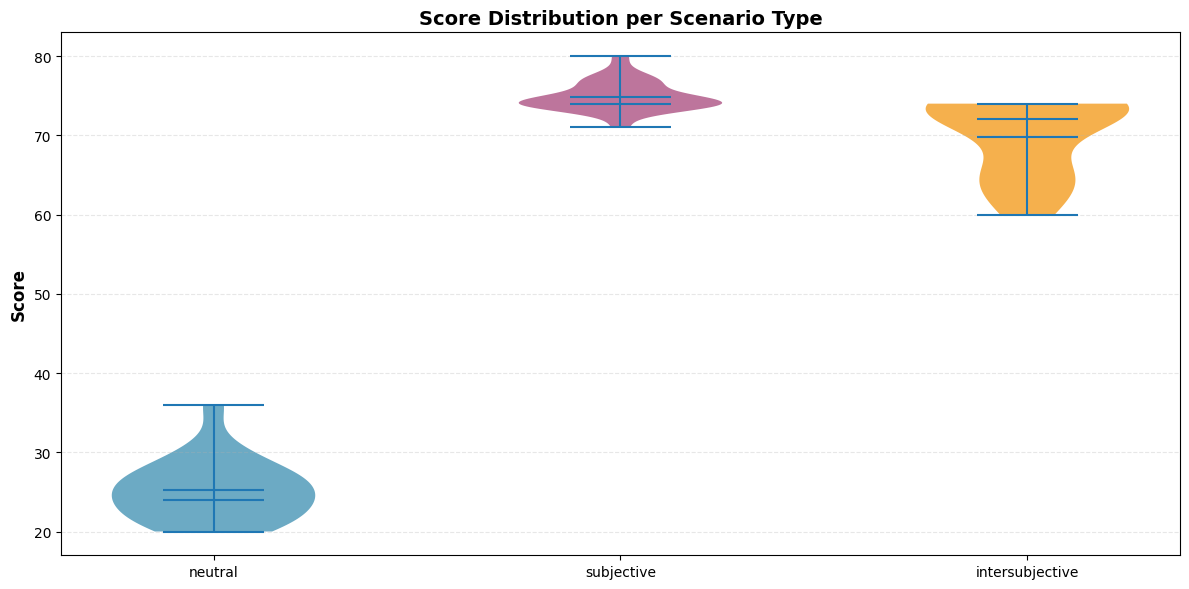


Statistics by scenario type:
  neutral:
    Mean: 25.20, Median: 24.00, Std: 3.90
  subjective:
    Mean: 74.90, Median: 74.00, Std: 1.92
  intersubjective:
    Mean: 69.85, Median: 72.00, Std: 5.00


In [102]:
# Create violin plots for each scenario type
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2E86AB', '#A23B72', '#F18F01']  # Nice pleasing colors: blue, magenta, orange
data_to_plot = [data[col] for col in data.columns]

# Create violin plot
parts = ax.violinplot(data_to_plot, positions=range(len(data.columns)), showmeans=True, showmedians=True)

# Customize colors
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)

ax.set_xticks(range(len(data.columns)))
ax.set_xticklabels(data.columns)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Score Distribution per Scenario Type', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nStatistics by scenario type:")
for col in data.columns:
    print(f"  {col}:")
    print(f"    Mean: {data[col].mean():.2f}, Median: {data[col].median():.2f}, Std: {data[col].std():.2f}")

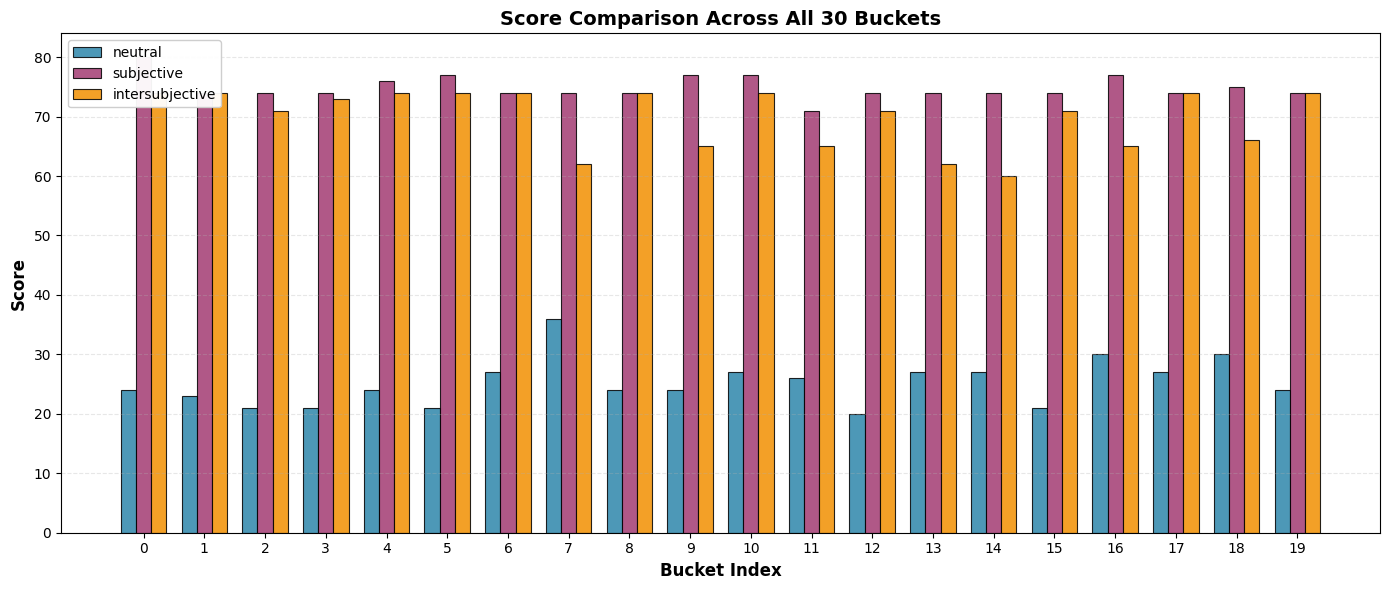


Total buckets: 20
Data summary statistics:
         neutral  subjective  intersubjective
count  20.000000   20.000000        20.000000
mean   25.200000   74.900000        69.850000
std     3.901417    1.916686         4.997631
min    20.000000   71.000000        60.000000
25%    22.500000   74.000000        65.000000
50%    24.000000   74.000000        72.000000
75%    27.000000   76.250000        74.000000
max    36.000000   80.000000        74.000000


In [87]:
# Create second histogram: comparison per index (all 30 buckets)
fig, ax = plt.subplots(figsize=(14, 6))

# Set up x-axis positions
x = np.arange(len(data))
width = 0.25

# Create bars for each column
for i, col in enumerate(data.columns):
    offset = (i - 1) * width  # Center the bars around the x positions
    ax.bar(x + offset, data[col], width, label=col, color=colors[i], alpha=0.85, edgecolor='black', linewidth=0.8)

ax.set_xlabel('Bucket Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Score Comparison Across All 30 Buckets', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{i}' for i in range(len(data))])
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nTotal buckets: {len(data)}")
print("Data summary statistics:")
print(data.describe())


In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both CSV files
data_8b = pd.read_csv('8b.csv')
data_70b = pd.read_csv('70b.csv')

print("8b.csv shape:", data_8b.shape)
print("70b.csv shape:", data_70b.shape)
print("\nFirst few rows of 8b.csv:")
print(data_8b.head())
print("\nFirst few rows of 70b.csv:")
print(data_70b.head())


8b.csv shape: (30, 3)
70b.csv shape: (20, 3)

First few rows of 8b.csv:
   neutral  subjective  intersubjective
0     29.0        64.0        67.000000
1     33.0        69.0        69.000000
2     40.0        64.0        61.000000
3     34.0        64.0        62.666667
4     32.0        66.0        66.000000

First few rows of 70b.csv:
   neutral  subjective  intersubjective
0     24.0        80.0             74.0
1     23.0        74.0             74.0
2     21.0        74.0             71.0
3     21.0        74.0             73.0
4     24.0        76.0             74.0


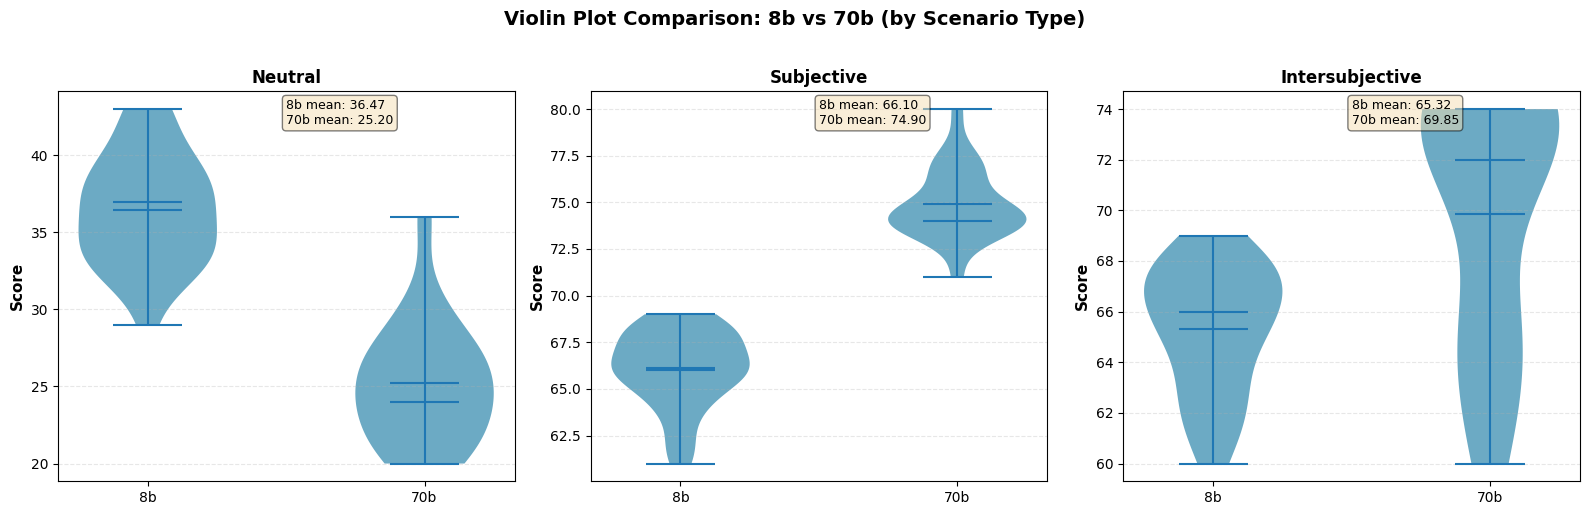


SUMMARY STATISTICS

NEUTRAL:
  8b  - Mean: 36.47, Std: 3.61, Min: 29.00, Max: 43.00
  70b - Mean: 25.20, Std: 3.90, Min: 20.00, Max: 36.00

SUBJECTIVE:
  8b  - Mean: 66.10, Std: 2.06, Min: 61.00, Max: 69.00
  70b - Mean: 74.90, Std: 1.92, Min: 71.00, Max: 80.00

INTERSUBJECTIVE:
  8b  - Mean: 65.32, Std: 2.50, Min: 60.00, Max: 69.00
  70b - Mean: 69.85, Std: 5.00, Min: 60.00, Max: 74.00


In [91]:
# Prepare data: Map columns to common names
col_mapping_8b = {'neut': 'neutral', 'sub': 'subjective', 'inter': 'intersubjective'}
col_mapping_70b = {'neutral': 'neutral', 'subjective': 'subjective', 'intersubjective': 'intersubjective'}

# Rename columns for consistency
data_8b_renamed = data_8b.rename(columns=col_mapping_8b)
data_70b_renamed = data_70b.rename(columns=col_mapping_70b)

columns = ['neutral', 'subjective', 'intersubjective']


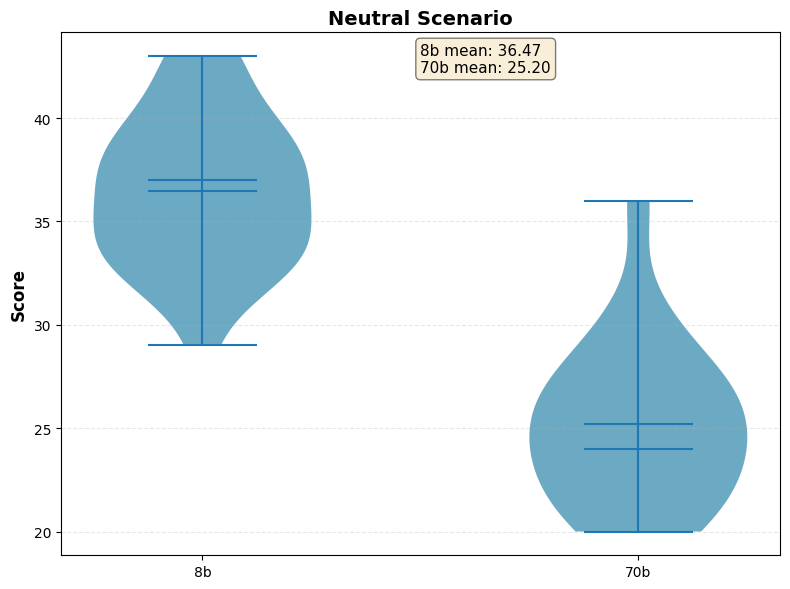


NEUTRAL:
  8b  - Mean: 36.47, Std: 3.61, Min: 29.00, Max: 43.00
  70b - Mean: 25.20, Std: 3.90, Min: 20.00, Max: 36.00


In [92]:
# Violin Plot: Neutral Scenario
fig, ax = plt.subplots(figsize=(8, 6))

col = 'neutral'
data_to_plot = [data_8b_renamed[col], data_70b_renamed[col]]

# Create violin plot
parts = ax.violinplot(data_to_plot, positions=[1, 2], showmeans=True, showmedians=True)

# Customize colors
for pc in parts['bodies']:
    pc.set_facecolor('#2E86AB')
    pc.set_alpha(0.7)

ax.set_xticks([1, 2])
ax.set_xticklabels(['8b', '70b'])
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Neutral Scenario', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add statistics
mean_8b = data_8b_renamed[col].mean()
mean_70b = data_70b_renamed[col].mean()
ax.text(0.5, 0.98, f'8b mean: {mean_8b:.2f}\n70b mean: {mean_70b:.2f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nNEUTRAL:")
print(f"  8b  - Mean: {data_8b_renamed[col].mean():.2f}, Std: {data_8b_renamed[col].std():.2f}, Min: {data_8b_renamed[col].min():.2f}, Max: {data_8b_renamed[col].max():.2f}")
print(f"  70b - Mean: {data_70b_renamed[col].mean():.2f}, Std: {data_70b_renamed[col].std():.2f}, Min: {data_70b_renamed[col].min():.2f}, Max: {data_70b_renamed[col].max():.2f}")


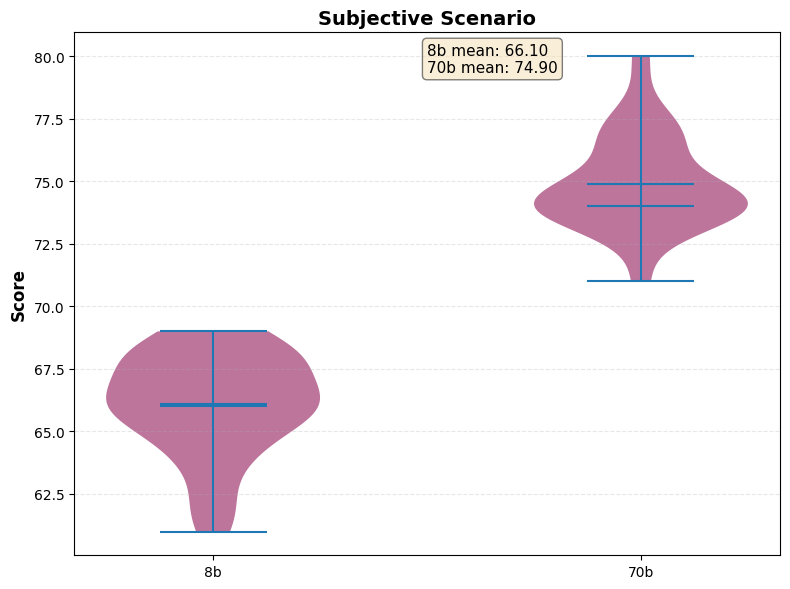


SUBJECTIVE:
  8b  - Mean: 66.10, Std: 2.06, Min: 61.00, Max: 69.00
  70b - Mean: 74.90, Std: 1.92, Min: 71.00, Max: 80.00


In [93]:
# Violin Plot: Subjective Scenario
fig, ax = plt.subplots(figsize=(8, 6))

col = 'subjective'
data_to_plot = [data_8b_renamed[col], data_70b_renamed[col]]

# Create violin plot
parts = ax.violinplot(data_to_plot, positions=[1, 2], showmeans=True, showmedians=True)

# Customize colors
for pc in parts['bodies']:
    pc.set_facecolor('#A23B72')
    pc.set_alpha(0.7)

ax.set_xticks([1, 2])
ax.set_xticklabels(['8b', '70b'])
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Subjective Scenario', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add statistics
mean_8b = data_8b_renamed[col].mean()
mean_70b = data_70b_renamed[col].mean()
ax.text(0.5, 0.98, f'8b mean: {mean_8b:.2f}\n70b mean: {mean_70b:.2f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nSUBJECTIVE:")
print(f"  8b  - Mean: {data_8b_renamed[col].mean():.2f}, Std: {data_8b_renamed[col].std():.2f}, Min: {data_8b_renamed[col].min():.2f}, Max: {data_8b_renamed[col].max():.2f}")
print(f"  70b - Mean: {data_70b_renamed[col].mean():.2f}, Std: {data_70b_renamed[col].std():.2f}, Min: {data_70b_renamed[col].min():.2f}, Max: {data_70b_renamed[col].max():.2f}")


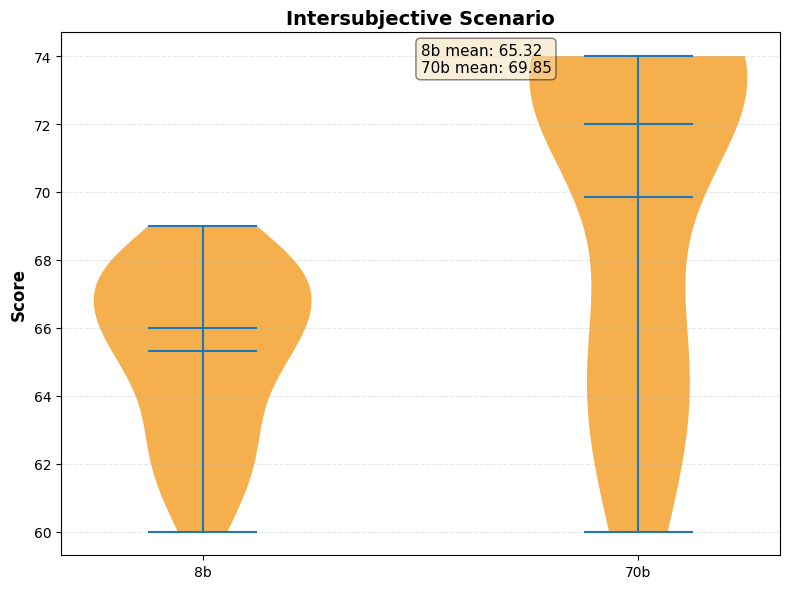


INTERSUBJECTIVE:
  8b  - Mean: 65.32, Std: 2.50, Min: 60.00, Max: 69.00
  70b - Mean: 69.85, Std: 5.00, Min: 60.00, Max: 74.00


In [94]:
# Violin Plot: Intersubjective Scenario
fig, ax = plt.subplots(figsize=(8, 6))

col = 'intersubjective'
data_to_plot = [data_8b_renamed[col], data_70b_renamed[col]]

# Create violin plot
parts = ax.violinplot(data_to_plot, positions=[1, 2], showmeans=True, showmedians=True)

# Customize colors
for pc in parts['bodies']:
    pc.set_facecolor('#F18F01')
    pc.set_alpha(0.7)

ax.set_xticks([1, 2])
ax.set_xticklabels(['8b', '70b'])
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Intersubjective Scenario', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add statistics
mean_8b = data_8b_renamed[col].mean()
mean_70b = data_70b_renamed[col].mean()
ax.text(0.5, 0.98, f'8b mean: {mean_8b:.2f}\n70b mean: {mean_70b:.2f}', 
        transform=ax.transAxes, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nINTERSUBJECTIVE:")
print(f"  8b  - Mean: {data_8b_renamed[col].mean():.2f}, Std: {data_8b_renamed[col].std():.2f}, Min: {data_8b_renamed[col].min():.2f}, Max: {data_8b_renamed[col].max():.2f}")
print(f"  70b - Mean: {data_70b_renamed[col].mean():.2f}, Std: {data_70b_renamed[col].std():.2f}, Min: {data_70b_renamed[col].min():.2f}, Max: {data_70b_renamed[col].max():.2f}")
